In [1]:
import pandas as pd
df = pd.read_csv('E:\Spam-Detection\data\spam.csv', encoding='latin-1')

In [2]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
## FE
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [7]:
df = df.rename(columns={'v1':'label','v2':'message'})

In [8]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape

(5572, 2)

In [10]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(5169, 2)

In [14]:
df['num_characters'] = df['message'].apply(len)

In [15]:
df.head()

,label,message,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [16]:
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import nltk 
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
from nltk.tokenize import word_tokenize,sent_tokenize
df['num_words'] = df['message'].apply(lambda x: len(word_tokenize(x)))
df['num_sentences'] = df['message'].apply(lambda x: len(sent_tokenize(x)))


In [19]:
df.head()

,label,message,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [20]:
df.describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [21]:
df.groupby('label').describe()

num_characters                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0   
spam           653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0   

      num_words             ...              num_sentences            \
          count       mean  ...   75%    max         count      mean   
label                       ...                                        
ham      4516.0  17.123782  ...  22.0  220.0        4516.0  1.820195   
spam      653.0  27.667688  ...  32.0   46.0         653.0  2.970904   

                                           
            std  min  25%  50%  75%   max  
label                                      
ham    1.383657  1.0  1.0  1.0  2.0  38.0  
spam   1.488425  1.0  2.0  3.0  4.0   9.0  

[2 rows x 24 columns]

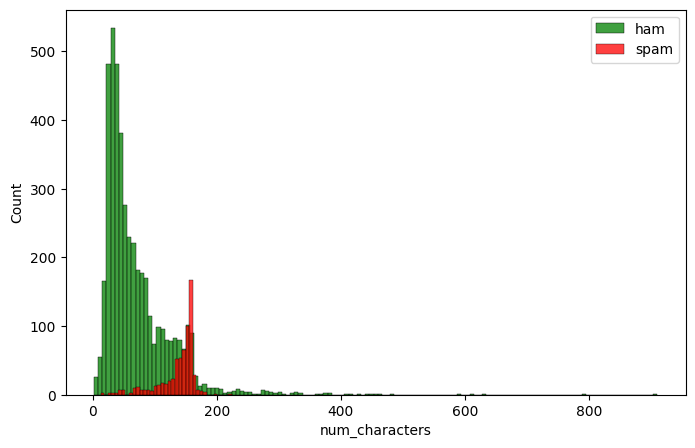

In [22]:
### EDA
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df[df['label'] == 'ham']['num_characters'], color='green',label='ham')
sns.histplot(df[df['label'] == 'spam']['num_characters'], color='red',label='spam')
plt.legend()
plt.show()

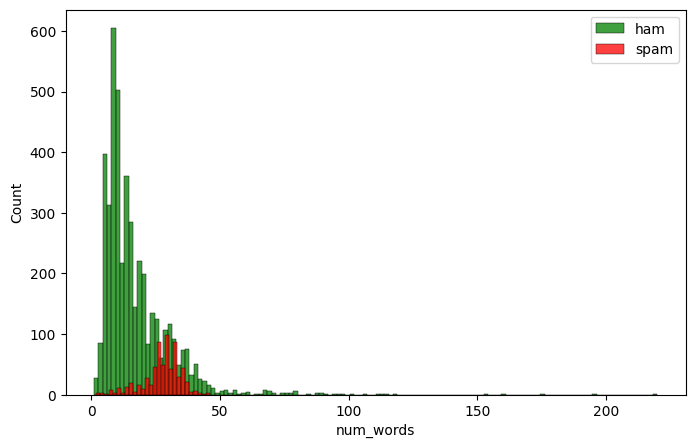

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['label'] == 'ham']['num_words'], color='green',label='ham')
sns.histplot(df[df['label'] == 'spam']['num_words'], color='red',label='spam')
plt.legend()
plt.show()

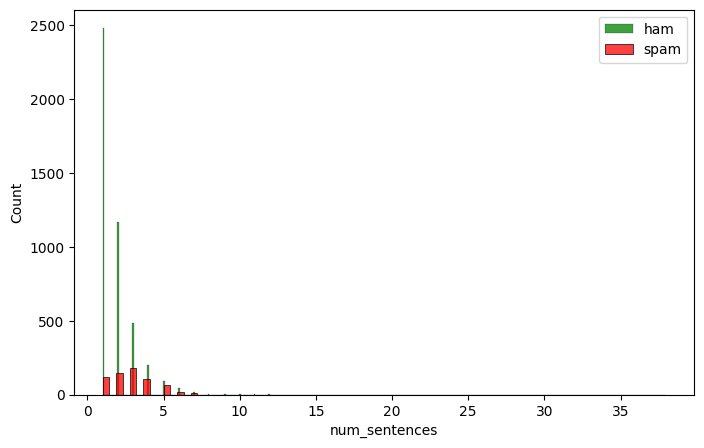

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['label'] == 'ham']['num_sentences'], color='green',label='ham')
sns.histplot(df[df['label'] == 'spam']['num_sentences'], color='red',label='spam')
plt.legend()
plt.show()

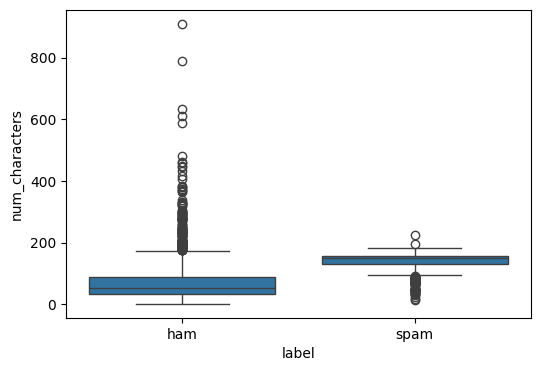

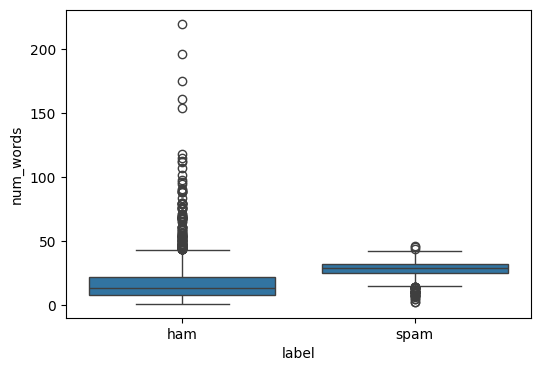

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='num_characters',data = df)
plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='num_words',data = df)
plt.show()

In [26]:
df['label_num'] = df['label'].map({'ham' : 0,'spam': 1})
df[['label_num','num_characters','num_words','num_sentences']].corr()

,label_num,num_characters,num_words,num_sentences
label_num,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


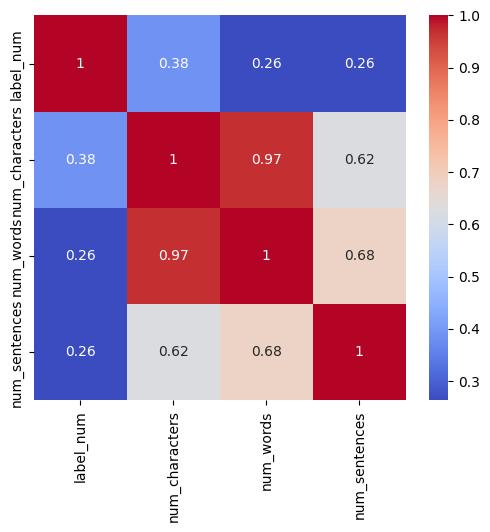

In [27]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['label_num','num_characters','num_words','num_sentences']].corr(),annot = True,cmap='coolwarm')
plt.show()

In [28]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
STOPWORDS = set(stopwords.words("english"))
def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y
    y = []
    for i in text:
        if i not in STOPWORDS:
            y.append(i)
    text = y
    y = []
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)


In [29]:
df['transformed_message'] = df['message'].apply(transform_text)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['transformed_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
tfidf = TfidfVectorizer(max_features = 3000)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9642166344294004
Confusion Matrix:
[[883   6]
 [ 31 114]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       889
           1       0.95      0.79      0.86       145

    accuracy                           0.96      1034
   macro avg       0.96      0.89      0.92      1034
weighted avg       0.96      0.96      0.96      1034



In [32]:
nb = MultinomialNB()
nb.fit(X_train,y_train)
y_pred_nb = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9680851063829787
Confusion Matrix:
[[888   1]
 [ 32 113]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.78      0.87       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [34]:
import pickle
pickle.dump(tfidf, open("E:/Spam-Detection/models/tfidf_vectorizer.pkl","wb"))
pickle.dump(lr, open("E:/Spam-Detection/models/model.pkl","wb"))

In [45]:
text = input('Enter Message : ')
text = transform_text(text)
vector = tfidf.transform([text])
prediction = lr.predict(vector)
if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham
